In [1]:
#%pip install mpl-axes-aligner
#%pip install factor_analyzer
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import mpl_axes_aligner
from factor_analyzer.rotator import Rotator

In [2]:
#Functions to make life simpler
def pca_func(pca_data, title_suffix=""):
    """Perform PCA and plot explained variance."""
    pca = PCA()
    pca_out = pca.fit_transform(pca_data)
    
    # --- Each plot gets its own figure ---
    plt.figure(figsize=(6, 4))
    plt.plot(pca.explained_variance_, marker='o')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance')
    plt.title(f'PCA Explained Variance{title_suffix}')
    
    # Print summary in terminal
    summary = pd.DataFrame({
        'Explained Variance Ratio': pca.explained_variance_ratio_,
        'Cumulative Explained Variance': pca.explained_variance_ratio_.cumsum()
    })
    print("\nExplained variance summary", title_suffix)
    print(summary)
    
    return pca, pca_out

In [3]:
# There is no biplot function in sklearn, so we create a simple one ourselves
#function to produce biplot
def biplot(dfScores: pd.DataFrame, dfLoadings: pd.DataFrame, pca, title="Biplot", new_axes=True) -> None:
    """Create a PCA biplot."""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Scores plot
    ax.scatter(dfScores.PC1.values, dfScores.PC2.values, s=5, color='b') # s = size
    if new_axes:
        explvar = 100 * pca.explained_variance_ratio_
        ax.set_xlabel(f"PC1 ({explvar[0]:.1f}% explained var.)", fontsize=10)
        ax.set_ylabel(f"PC2 ({explvar[1]:.1f}% explained var.)", fontsize=10)
    else:
        ax.set_xlabel("PC1", fontsize=10)
        ax.set_ylabel("PC2", fontsize=10)
    
    # Second axes for loadings
    ax2 = ax.twinx().twiny()
    font = {'color': 'g', 'weight': 'bold', 'size': 10}
    
    # Loading vectors
    for col in dfLoadings.columns.values:
        tipx = dfLoadings.loc['PC1', col]
        tipy = dfLoadings.loc['PC2', col]
        ax2.arrow(0, 0, tipx, tipy, color='r', alpha=0.5)
        ax2.text(tipx * 1.05, tipy * 1.05, col, fontdict=font,
                 ha='center', va='center')
    
    # Align axes and fix square aspect ratio
    mpl_axes_aligner.align.xaxes(ax, 0, ax2, 0, 0.5)
    mpl_axes_aligner.align.yaxes(ax, 0, ax2, 0, 0.5)
    ax.set_aspect('equal', adjustable='datalim')
    ax2.set_aspect('equal', adjustable='datalim')
    
    plt.title(title)
    plt.tight_layout()

In [10]:
# Load Data
df = pd.read_csv('data/USA2016data.csv')
print(df.head())

   population2014  population2010  population_change  ageunder5  ageunder18  \
0           55395           54571                1.5        6.0        25.2   
1          200111          182265                9.8        5.6        22.2   
2           26887           27457               -2.1        5.7        21.2   
3           22506           22919               -1.8        5.3        21.0   
4           57719           57322                0.7        6.1        23.6   

   age65plus  femaleperc  white  black  native  ...  houses  houseown  \
0       13.8        51.4   77.9   18.7     0.5  ...   22751      76.8   
1       18.7        51.2   87.1    9.6     0.7  ...  107374      72.6   
2       16.5        46.6   50.2   47.6     0.6  ...   11799      67.7   
3       14.8        45.9   76.3   22.1     0.4  ...    8978      79.0   
4       17.0        50.5   96.0    1.8     0.6  ...   23826      81.0   

   housemulti  households  pphousehold  income  poverty  retailsales  \
0         8.3 

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



Data shape for PCA: (3112, 32)

Explained variance summary  on USA 2016 Data
    Explained Variance Ratio  Cumulative Explained Variance
0               2.441012e-01                       0.244101
1               1.543600e-01                       0.398461
2               9.028624e-02                       0.488747
3               7.624109e-02                       0.564989
4               6.361583e-02                       0.628604
5               5.587330e-02                       0.684478
6               4.982292e-02                       0.734301
7               3.745943e-02                       0.771760
8               3.525375e-02                       0.807014
9               2.928232e-02                       0.836296
10              2.309611e-02                       0.859392
11              2.076659e-02                       0.880159
12              1.916347e-02                       0.899322
13              1.882903e-02                       0.918151
14              1.5884

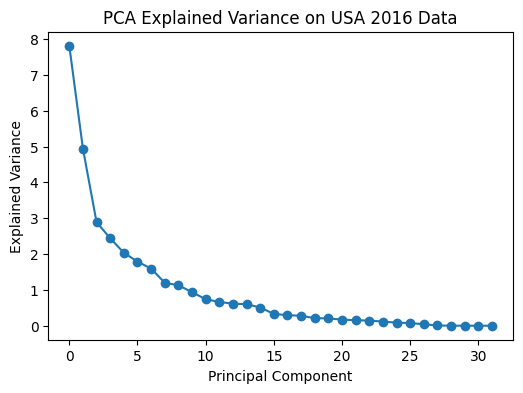

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


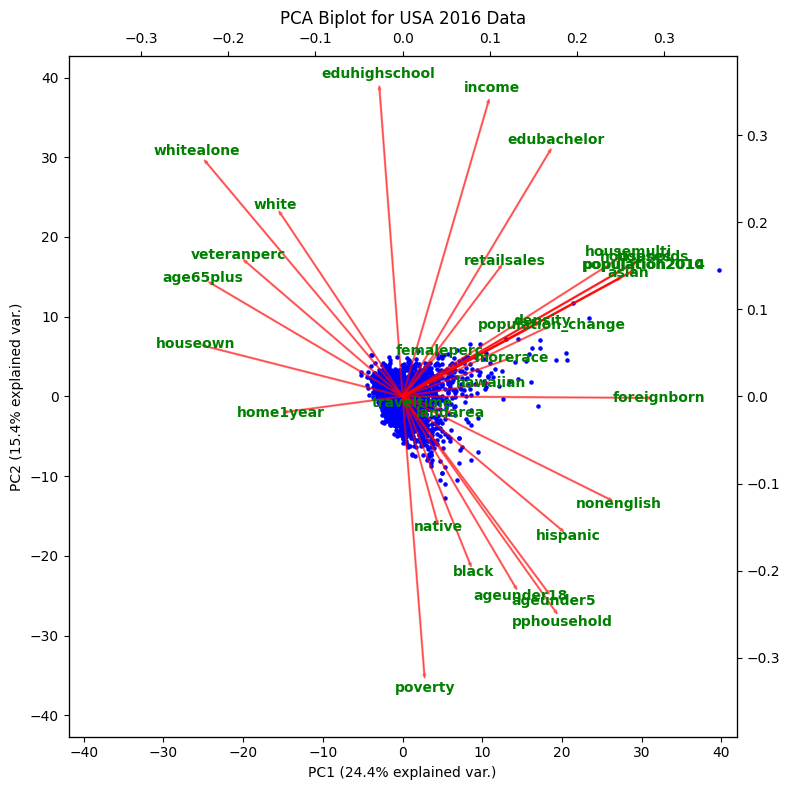

In [12]:
# Select numeric columns for PCA
numeric_cols = df.select_dtypes(include=['number']).columns
pca_data = df[numeric_cols].dropna() # Drop rows with missing values
print(f"\nData shape for PCA: {pca_data.shape}")
# Standardize the data
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)
pca_data_scaled_df = pd.DataFrame(pca_data_scaled, columns=numeric_cols)

# Perform PCA
pca, pca_out = pca_func(pca_data_scaled_df, title_suffix=" on USA 2016 Data")
# Prepare scores and loadings DataFrames
dfScores = pd.DataFrame(pca_out, columns=[f'PC{i+1}' for i in range(pca_out.shape[1])])
dfLoadings = pd.DataFrame(pca.components_.T, index=numeric_cols, columns=[f'PC{i+1}' for i in range(pca_out.shape[1])]).T
# Create biplot
biplot(dfScores, dfLoadings, pca, title="PCA Biplot for USA 2016 Data", new_axes=True)
plt.show()  
